## ⚙️ Execution Environment

This notebook was originally developed and run using Google Colab with Google Drive integration.

As a result, some file paths use:
`/content/drive/MyDrive/...`

### Running Locally

To run this notebook locally:

- Replace Google Drive paths with local paths (e.g., `BASE_PATH`)
- Ensure required files (datasets, pipelines) are placed in the appropriate directories
- Install dependencies from `requirements.txt`

### Note

This notebook is preserved in its original form to reflect the development workflow.  
A cleaned and fully local version of the pipeline is available in the main project structure. 

# Setup

In [68]:
# --- Prelim Imports --- #

import pandas as pd
import joblib
import numpy as np
import random
import matplotlib.pyplot as plt

# --- Imports for Models --- #

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


In [ ]:
# --- Drive Loading and seed --- #

from google.colab import drive
drive.mount('/content/drive')
np.random.seed(42)
random.seed(42)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
# --- Helpers --- #

def evaluate_model(name, model, X_train, X_test, y_train, y_test, threshold=0.50):
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Model": name,
        "Threshold": threshold,
        "Accuracy (Exploratory Only)": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob)
    }


# Preliminary Exploration and Base Model Setup

In [71]:
# ---- Cluster 3 Subgroup Modeling: Load Data ---- #

cluster3 = pd.read_csv("/content/drive/MyDrive/Applications of ML/Cluster Datasets/cluster_3.csv")
selected_features = joblib.load("/content/drive/MyDrive/Applications of ML/Pipelines/selected_features.pkl")

print("Cluster 3 shape:", cluster3.shape)
print(cluster3["Bankrupt?"].value_counts())
print(cluster3["Bankrupt?"].mean())

X_cluster3 = cluster3[selected_features].copy()
y_cluster3 = cluster3["Bankrupt?"].copy()

print("X shape:", X_cluster3.shape)
print("y shape:", y_cluster3.shape)

Cluster 3 shape: (947, 98)
Bankrupt?
0    804
1    143
Name: count, dtype: int64
0.15100316789862725
X shape: (947, 50)
y shape: (947,)


All 947 companies/features loaded correctly. Feature Reduction starts now.

In [72]:
# ---- Cluster 3 Internal Feature Ranking ---- #

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_cluster3, y_cluster3)

importances = pd.Series(
    rf.feature_importances_,
    index=X_cluster3.columns
).sort_values(ascending=False)

print(importances.head(20))

Equity to Liability                                        0.061986
Borrowing dependency                                       0.053593
Total debt/Total net worth                                 0.051039
Debt ratio %                                               0.051006
Net Value Growth Rate                                      0.044552
Quick Ratio                                                0.037906
Persistent EPS in the Last Four Seasons                    0.032702
Net Income to Stockholder's Equity                         0.032548
Current Liabilities/Equity                                 0.027818
Net Value Per Share (B)                                    0.025399
ROA(C) before interest and depreciation before interest    0.023251
Accounts Receivable Turnover                               0.022908
Interest-bearing debt interest rate                        0.022684
Average Collection Days                                    0.021902
Inventory/Working Capital                       

### Cluster 3 Feature Ranking

After loading Cluster 3, I started with the same 50 features used during the clustering stage. Since each subgroup may have its own reduced feature set, similar to the clustering stage for feature reduction, I used a Random Forest classifier to rank feature importance specifically within Cluster 3.

The most important features for Cluster 3 were mainly related to leverage, debt burden, and profitability. The top features included Equity to Liability, Borrowing Dependency, Total Debt to Total Net Worth, Debt Ratio %, Net Value Growth Rate, and Quick Ratio.

Based on this ranking, I will select a smaller set of features from the original 50 and use the same selected feature set for all base models in the Cluster 3 stacking model. I may choose to come back and reduce this further - or alternatively add more - depending on how my experiments go.

In [73]:
# ---- Cluster 3 Feature Setting ---- #

cluster3_features = importances.head(20).index.tolist()
X_cluster3_selected = X_cluster3[cluster3_features].copy()

print("Selected feature count:", len(cluster3_features))
cluster3_features

Selected feature count: 20


[' Equity to Liability',
 ' Borrowing dependency',
 ' Total debt/Total net worth',
 ' Debt ratio %',
 ' Net Value Growth Rate',
 ' Quick Ratio',
 ' Persistent EPS in the Last Four Seasons',
 " Net Income to Stockholder's Equity",
 ' Current Liabilities/Equity',
 ' Net Value Per Share (B)',
 ' ROA(C) before interest and depreciation before interest',
 ' Accounts Receivable Turnover',
 ' Interest-bearing debt interest rate',
 ' Average Collection Days',
 ' Inventory/Working Capital',
 ' Revenue per person',
 ' Pre-tax net Interest Rate',
 ' Total assets to GNP price',
 ' Retained Earnings to Total Assets',
 ' Non-industry income and expenditure/revenue']

I will keep in mind that my three base models should not be the same style, such as three "tree" models, because then the meta model might not have as much value. I want to be able to interpret the three base models for their unique strengths and then come to a final decision.

With that, knowing that Cluster 3 is a dataset filled with distressed companies, it might be a good idea to do:

1. Logistic Regression for its clean signals and stable baseline.
2. Random Forest for its ability to read through the noisy data and ratio interactions.
3. Support Vector Classifier to try to seperate between distressed and healthy companies.

In [74]:
# --- Split and Model Setup --- #

X_train, X_test, y_train, y_test = train_test_split(
    X_cluster3_selected,
    y_cluster3,
    test_size=0.20,
    stratify=y_cluster3,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train positives:", y_train.sum())
print("y_test positives :", y_test.sum())

# Base Models
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

svc = SVC(
    probability=True,
    class_weight="balanced",
    random_state=42
)

X_train: (757, 20)
X_test : (190, 20)
y_train positives: 114
y_test positives : 29


We split the Training and Test sets into 757 and 190 companies, respectively. We also keep the ratio of bankrupt/non-bankrupt balanced across the two sets. Now our next step should be to see how each model performs alone - lets fit each model and compare them.

In [75]:
# ---- Fit Base Models ---- #

# Logistic Regression
lr.fit(X_train, y_train)

# Random Forest
rf.fit(X_train, y_train)

# Support Vector Classifier
svc.fit(X_train, y_train)

print("All three base models fitted successfully.")

All three base models fitted successfully.


In [76]:
# ---- Evaluate Base Models ---- #

results = []

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVC": svc
}

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, auc])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.721053,0.166667,0.206897,0.184615,0.416470
1,Random Forest,0.863158,0.615385,0.275862,0.380952,0.878239
2,SVC,0.847368,0.000000,0.000000,0.000000,0.417862


While at first the accuracy score might look promising, its likely important to remember that predicting non-bankruptcy is relatively safe. Our goal is deteict bankruptcy, so the metrics to look at might be more focused at:

- Recall tells us how many bankruptcies were caught.
- F1 tells us the balance between catching bankruptcies and being accurate.
- and lastly AUC gives us a ranking ability.

Logistic Regression: only caught roughly 21% of bankruptcies, with a low AUC, it's also not ranking the bankrupt companies that well. Tuning will be required here.

Random Forest: Caught roughly 28% of bankrupcties, with a very strong precision of 62% and an AUC of 88%. This would be our leading model so far.

SVC: Did not catch any bankruptcies, it graded each sample as non-bankrupt. It likely was too conservative, I might have to change this model or at least look to greatly tuning it.



In [77]:
# ---- Tune Logistic Regression ---- #
log_results = []

for c in [0.01, 0.1, 1, 5, 10]:

    model = LogisticRegression(
        C=c,
        class_weight="balanced",
        solver="liblinear",
        max_iter=3000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob >= 0.35).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    log_results.append([c, acc, prec, rec, f1, auc])

pd.DataFrame(
    log_results,
    columns=["C","Accuracy","Precision","Recall","F1","AUC"]
)

,C,Accuracy,Precision,Recall,F1,AUC
0,0.01,0.147368,0.144385,0.931034,0.25,0.447848
1,0.10,0.147368,0.144385,0.931034,0.25,0.447848
2,1.00,0.147368,0.144385,0.931034,0.25,0.447848
3,5.00,0.147368,0.144385,0.931034,0.25,0.447848
4,10.00,0.147368,0.144385,0.931034,0.25,0.447848


Interestingly, the C values were not the bottleneck for logistic regression. However, we also changed the threshold to 0.35, and it suddenly became super aggressive at predicting bankruptcies. The lower accuracy tells us that its marking most healthy companies as bankrupt as well.

Lets tune it a bit more.

In [78]:
# ---- Logistic Threshold Sweep ---- #

log_model = LogisticRegression(
    C=1,
    class_weight="balanced",
    solver="liblinear",
    max_iter=3000,
    random_state=42
)

log_model.fit(X_train, y_train)

# Get probabilities
y_prob = log_model.predict_proba(X_test)[:, 1]

threshold_results = []

for t in [0.30, 0.35, 0.40, 0.45, 0.50]:

    y_pred = (y_prob >= t).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    threshold_results.append([t, acc, prec, rec, f1, auc])

pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

,Threshold,Accuracy,Precision,Recall,F1,AUC
0,0.30,0.152632,0.148936,0.965517,0.258065,0.447848
1,0.35,0.147368,0.144385,0.931034,0.250000,0.447848
2,0.40,0.147368,0.144385,0.931034,0.250000,0.447848
3,0.45,0.147368,0.144385,0.931034,0.250000,0.447848
4,0.50,0.531579,0.159091,0.482759,0.239316,0.447848


It appears that logistic regression was less effective as a standalone model here, but it could have uses as a aggressive recall voice within the stack. It has the ability to at least check for bankruptcies aggressively. I will keep the threshold at 0.30 and keep that as the system for the logistic regression model.

Final Logistic Regression setup:
- `C = 1`
- `class_weight = "balanced"`
- `solver = "liblinear"`
- threshold considered: `0.30`
- Use:  Its role in the stack is to provide a high-recall signal.

In [79]:
# ---- Final Logistic Regression Model ---- #

final_lr = LogisticRegression(
    C=1,
    class_weight="balanced",
    solver="liblinear",
    max_iter=3000,
    random_state=42
)

final_lr.fit(X_train, y_train)

logistic_threshold = 0.30

In [80]:
# ---- Random Forest Threshold Sweep ---- #

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Fit final-style Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

# Get probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

rf_threshold_results = []

for t in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:

    y_pred_rf = (y_prob_rf >= t).astype(int)

    acc = accuracy_score(y_test, y_pred_rf)
    prec = precision_score(y_test, y_pred_rf, zero_division=0)
    rec = recall_score(y_test, y_pred_rf)
    f1 = f1_score(y_test, y_pred_rf)
    auc = roc_auc_score(y_test, y_prob_rf)

    rf_threshold_results.append([t, acc, prec, rec, f1, auc])

pd.DataFrame(
    rf_threshold_results,
    columns=["Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

,Threshold,Accuracy,Precision,Recall,F1,AUC
0,0.15,0.747368,0.366197,0.896552,0.520000,0.878239
1,0.20,0.821053,0.452830,0.827586,0.585366,0.878239
2,0.25,0.868421,0.550000,0.758621,0.637681,0.878239
3,0.30,0.847368,0.500000,0.551724,0.524590,0.878239
4,0.35,0.852632,0.518519,0.482759,0.500000,0.878239
5,0.40,0.868421,0.583333,0.482759,0.528302,0.878239
6,0.45,0.847368,0.500000,0.344828,0.408163,0.878239
7,0.50,0.857895,0.571429,0.275862,0.372093,0.878239


Random Forest (RF) tuning shows us that a threshold of 0.25 gives us:
- Best F1 score: 0.638

Best balanced performance:
- Strong accuracy: 0.868
- Strong Recall: 0.759
- Strong Precision 0.550

Tuning to 0.15 catches almost all bankruptcies but it becomes a bit unreliable, low precision, while tuning to 0.40 seems a bit more conservative, but slightly cleaner predicitons.

Final Random Forest setup:
- `n_estimators = 300`
- `class_weight = "balanced"`
- `random_state = 42`
- threshold considered: `0.25`
- Use: Its role in the stack is to provide the strongest balanced prediction signal, combining solid recall with good precision.

In [81]:
# ---- Final Random Forest Model ---- #
final_rf = rf_model
rf_threshold = 0.25

In [82]:
# ---- Tune SVC ---- #

svc_results = []

for c in [0.1, 1, 5, 10]:
    for gamma in ["scale", 0.01, 0.05, 0.1]:

        model = SVC(
            C=c,
            gamma=gamma,
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]

        # Try a lower threshold since default 0.50 predicted all zeros
        y_pred = (y_prob >= 0.30).astype(int)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        svc_results.append([c, gamma, acc, prec, rec, f1, auc])

svc_results_df = pd.DataFrame(
    svc_results,
    columns=["C", "Gamma", "Accuracy", "Precision", "Recall", "F1", "AUC"]
).sort_values(by="F1", ascending=False)

svc_results_df.head(10)

,C,Gamma,Accuracy,Precision,Recall,F1,AUC
14,10.0,0.05,0.778947,0.314286,0.379310,0.343750,0.721354
11,5.0,0.1,0.778947,0.314286,0.379310,0.343750,0.721354
15,10.0,0.1,0.784211,0.312500,0.344828,0.327869,0.728636
7,1.0,0.1,0.778947,0.303030,0.344828,0.322581,0.737952
10,5.0,0.05,0.778947,0.303030,0.344828,0.322581,0.723495
13,10.0,0.01,0.821053,0.352941,0.206897,0.260870,0.736989
2,0.1,0.05,0.847368,0.000000,0.000000,0.000000,0.208396
0,0.1,scale,0.847368,0.000000,0.000000,0.000000,0.381880
6,1.0,0.05,0.847368,0.000000,0.000000,0.000000,0.768259
5,1.0,0.01,0.847368,0.000000,0.000000,0.000000,0.207967


Originally, our SVC was very conservative with zero Recall and F1, but with some tuning, we were able to raise the C higher, add a moderate gamma and a lower threshold. At C = 10 and a 0.05 gamma, we are able to get a F1 score that has a decent AUC score with it.

Final SVC setup:

- `kernel = "rbf"`
- `C = 10`
- `gamma = 0.05`
- `probability = True`
- `class_weight = "balanced"`
- threshold considered: `0.30`
- Use: Its role in the stack is to provide a boundary-based classification signal that differs from Logistic Regression and Random Forest.

In [83]:
final_svc = SVC(
    kernel="rbf",
    C=10,
    gamma=0.05,
    probability=True,
    class_weight="balanced",
    random_state=42
)

final_svc.fit(X_train, y_train)

svc_threshold = 0.30

Now, before doing the Meta model, I want to take a look at the feature space for each base model and analyze its health and how its learning. If I notice that the feature space should be tuned further, or if a model could be replaced, then I should do that at this step before finalizing decisions.

For each model, I'll display its confusion matrix, its classification report, and its probability behavior. For features we will take a look at its support patterns and coeffficients, and lastly we will do some visualizations of the  top features to see if anything needs pruning/optimizations.

                                              Feature   Coefficient  \
11                       Accounts Receivable Turnover -1.224746e-08   
13                            Average Collection Days -4.693747e-09   
15                                 Revenue per person  3.831827e-09   
12                Interest-bearing debt interest rate -8.419145e-10   
4                               Net Value Growth Rate  4.758713e-10   
17                          Total assets to GNP price -9.606472e-11   
3                                        Debt ratio %  5.594304e-14   
10   ROA(C) before interest and depreciation befor... -4.017182e-14   
2                          Total debt/Total net worth  2.596347e-14   
6             Persistent EPS in the Last Four Seasons -1.867566e-14   
1                                Borrowing dependency  1.697314e-14   
8                          Current Liabilities/Equity  1.626369e-14   
7                  Net Income to Stockholder's Equity -1.358571e-14   
0     

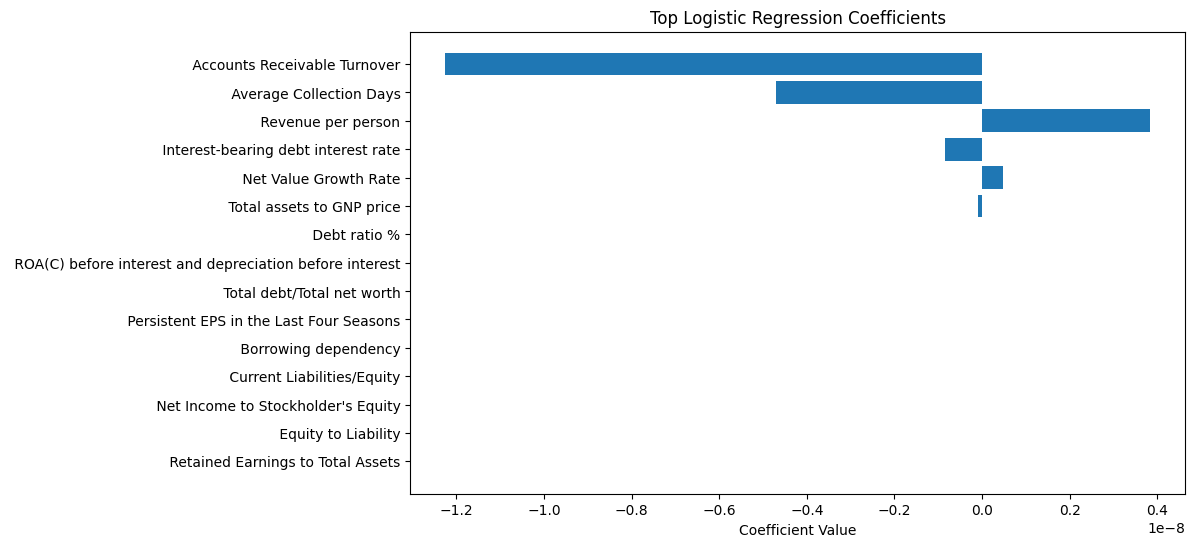

In [84]:
# ---- Logistic Regression Feature Analysis ---- #

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": final_lr.coef_[0]
})

coef_df["Abs"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values("Abs", ascending=False)

print(coef_df.head(15))

plt.figure(figsize=(10,6))
plt.barh(coef_df["Feature"].head(15), coef_df["Coefficient"].head(15))
plt.gca().invert_yaxis()
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

The strongest logistic regression coefficients that contribute to negative pushes are:
- Accounts Receivable Turnover (Very High)
- Average Collection Days (High)
- Interest-bearing debt interest rate (Low - Moderate)

The strongest logistic regression coefficients that contribute to positive pushes are:

- Revenue per person (High)
- Net Value Growth Rate (Low)

The coefficients themselves are very small, likely due to the features not being scaled - which logistic regression and SVC are sensitive to. Let me go ahead and scale the models for logistic regression and SVC to see if we can make these coefficients more meaningful.

In [85]:
# ---- Scale Data for Logistic Regression and SVC ---- #

from sklearn.preprocessing import StandardScaler

scaler_sub = StandardScaler()

X_train_scaled = scaler_sub.fit_transform(X_train)
X_test_scaled  = scaler_sub.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)

Scaled train shape: (757, 20)
Scaled test shape : (190, 20)


In [86]:
# ---- Refit Logistic Regression on Scaled Data ---- #

scaled_log_model = LogisticRegression(
    C=1,
    class_weight="balanced",
    solver="liblinear",
    max_iter=3000,
    random_state=42
)

scaled_log_model.fit(X_train_scaled, y_train)

y_prob_scaled_log = scaled_log_model.predict_proba(X_test_scaled)[:, 1]

scaled_log_results = []

for t in [0.30, 0.35, 0.40, 0.45, 0.50]:

    y_pred_scaled_log = (y_prob_scaled_log >= t).astype(int)

    acc = accuracy_score(y_test, y_pred_scaled_log)
    prec = precision_score(y_test, y_pred_scaled_log, zero_division=0)
    rec = recall_score(y_test, y_pred_scaled_log)
    f1 = f1_score(y_test, y_pred_scaled_log)
    auc = roc_auc_score(y_test, y_prob_scaled_log)

    scaled_log_results.append([t, acc, prec, rec, f1, auc])

pd.DataFrame(
    scaled_log_results,
    columns=["Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)



,Threshold,Accuracy,Precision,Recall,F1,AUC
0,0.30,0.500000,0.215517,0.862069,0.344828,0.708503
1,0.35,0.557895,0.233010,0.827586,0.363636,0.708503
2,0.40,0.621053,0.252874,0.758621,0.379310,0.708503
3,0.45,0.684211,0.281690,0.689655,0.400000,0.708503
4,0.50,0.731579,0.322581,0.689655,0.439560,0.708503


In [87]:
# ---- Compare Unscaled vs Scaled Logistic ---- #

unscaled_df = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

scaled_df = pd.DataFrame(
    scaled_log_results,
    columns=["Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

unscaled_df["Version"] = "Unscaled"
scaled_df["Version"] = "Scaled"

compare_log_df = pd.concat([unscaled_df, scaled_df], ignore_index=True)

compare_log_df

,Threshold,Accuracy,Precision,Recall,F1,AUC,Version
0,0.30,0.152632,0.148936,0.965517,0.258065,0.447848,Unscaled
1,0.35,0.147368,0.144385,0.931034,0.250000,0.447848,Unscaled
2,0.40,0.147368,0.144385,0.931034,0.250000,0.447848,Unscaled
3,0.45,0.147368,0.144385,0.931034,0.250000,0.447848,Unscaled
4,0.50,0.531579,0.159091,0.482759,0.239316,0.447848,Unscaled
5,0.30,0.500000,0.215517,0.862069,0.344828,0.708503,Scaled
6,0.35,0.557895,0.233010,0.827586,0.363636,0.708503,Scaled
7,0.40,0.621053,0.252874,0.758621,0.379310,0.708503,Scaled
8,0.45,0.684211,0.281690,0.689655,0.400000,0.708503,Scaled
9,0.50,0.731579,0.322581,0.689655,0.439560,0.708503,Scaled


### Logistic Regression Final Revision (Scaled Features)

Because Logistic Regression is sensitive to feature magnitude, we used  `StandardScaler` onto our feature set for Cluster 3 and the model was retrained.

A direct comparison between the unscaled and scaled versions showed a major improvement in predictive quality. The unscaled model produced weak ranking performance (AUC = 0.447), while the scaled model improved to AUC = 0.708.

Threshold testing was then repeated on the scaled model. The best overall result occurred at a threshold of **0.50**, which produced the highest F1 score while maintaining balanced recall and precision.

This confirms that Logistic Regression should only be used with scaled inputs for this subgroup.

Final Logistic Regression setup:

- `StandardScaler()`
- `C = 1`
- `class_weight = "balanced"`
- `solver = "liblinear"`
- `max_iter = 3000`
- threshold considered: `0.50`
- Use: Its role in the stack is to provide a stable linear prediction signal after proper scaling.

In [88]:
# ---- Final Logistic Regression Model (Scaled) ---- #

final_lr_scaler = StandardScaler()

X_train_scaled_final = final_lr_scaler.fit_transform(X_train)
X_test_scaled_final = final_lr_scaler.transform(X_test)

final_lr = LogisticRegression(
    C=1,
    class_weight="balanced",
    solver="liblinear",
    max_iter=3000,
    random_state=42
)

final_lr.fit(X_train_scaled_final, y_train)

logistic_threshold = 0.50

In [89]:
# ---- Tune SVC on Scaled Data ---- #

svc_scaled_results = []

for c in [0.1, 1, 5, 10]:
    for gamma in ["scale", 0.01, 0.05, 0.1]:

        model = SVC(
            C=c,
            gamma=gamma,
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_train_scaled_final, y_train)

        y_prob = model.predict_proba(X_test_scaled_final)[:, 1]

        for t in [0.30, 0.35, 0.40, 0.45, 0.50]:

            y_pred = (y_prob >= t).astype(int)

            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            auc = roc_auc_score(y_test, y_prob)

            svc_scaled_results.append([c, gamma, t, acc, prec, rec, f1, auc])

svc_scaled_results_df = pd.DataFrame(
    svc_scaled_results,
    columns=["C", "Gamma", "Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"]
).sort_values(by="F1", ascending=False)

svc_scaled_results_df.head(15)

,C,Gamma,Threshold,Accuracy,Precision,Recall,F1,AUC
5,0.1,0.01,0.30,0.810526,0.410256,0.551724,0.470588,0.791176
0,0.1,scale,0.30,0.789474,0.372093,0.551724,0.444444,0.787321
10,0.1,0.05,0.30,0.789474,0.372093,0.551724,0.444444,0.787321
76,10.0,0.1,0.35,0.847368,0.500000,0.379310,0.431373,0.726066
75,10.0,0.1,0.30,0.821053,0.413793,0.413793,0.413793,0.726066
65,10.0,0.01,0.30,0.789474,0.351351,0.448276,0.393939,0.752410
46,5.0,0.01,0.35,0.805263,0.375000,0.413793,0.393443,0.755515
66,10.0,0.01,0.35,0.800000,0.363636,0.413793,0.387097,0.752410
15,0.1,0.1,0.30,0.773684,0.325000,0.448276,0.376812,0.783894
6,0.1,0.01,0.35,0.805263,0.366667,0.379310,0.372881,0.791176


In [90]:
# ---- Compare Best Unscaled vs Best Scaled SVC ---- #

svc_compare = pd.DataFrame([
    ["Unscaled Best", 10, 0.05, 0.30, 0.314286, 0.379310, 0.343750, 0.721354],
    ["Scaled Best",   0.1, 0.01, 0.30, 0.410256, 0.551724, 0.470588, 0.791176]
], columns=[
    "Version","C","Gamma","Threshold",
    "Precision","Recall","F1","AUC"
])

svc_compare

,Version,C,Gamma,Threshold,Precision,Recall,F1,AUC
0,Unscaled Best,10.0,0.05,0.3,0.314286,0.379310,0.343750,0.721354
1,Scaled Best,0.1,0.01,0.3,0.410256,0.551724,0.470588,0.791176


Similar to logistic regression, we re-trained on scaled feature space and found  the best overall result was achieved with:

- `C = 0.1`
- `gamma = 0.01`
- threshold considered: `0.30`

Final SVC setup:

- `StandardScaler()`
- `kernel = "rbf"`
- `C = 0.1`
- `gamma = 0.01`
- `probability = True`
- `class_weight = "balanced"`
- threshold considered: `0.30`
- Use: Its role in the stack is to provide a nonlinear boundary-based prediction signal that differs from Logistic Regression and Random Forest.

In [91]:
# ---- Final SVC Model (Scaled) ---- #

final_svc = SVC(
    kernel="rbf",
    C=0.1,
    gamma=0.01,
    probability=True,
    class_weight="balanced",
    random_state=42
)

final_svc.fit(X_train_scaled_final, y_train)

svc_threshold = 0.30

In [92]:
# ---- Final Logistic Coefficients (Scaled) ---- #

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": final_lr.coef_[0]
})

coef_df["Abs"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values("Abs", ascending=False)

coef_df.head(20)

,Feature,Coefficient,Abs
0,Equity to Liability,-1.640688,1.640688
1,Borrowing dependency,1.343739,1.343739
11,Accounts Receivable Turnover,-0.639816,0.639816
7,Net Income to Stockholder's Equity,0.632420,0.632420
6,Persistent EPS in the Last Four Seasons,-0.495072,0.495072
10,ROA(C) before interest and depreciation befor...,-0.403738,0.403738
5,Quick Ratio,-0.400915,0.400915
16,Pre-tax net Interest Rate,0.325928,0.325928
8,Current Liabilities/Equity,-0.320546,0.320546
17,Total assets to GNP price,-0.316248,0.316248


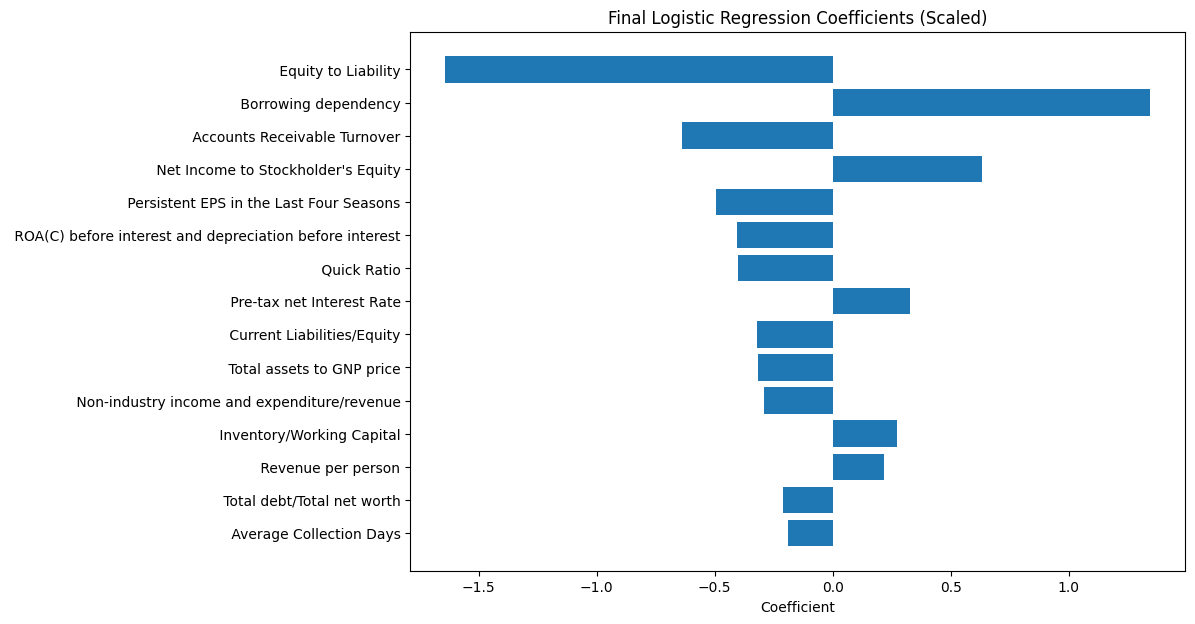

In [93]:
plt.figure(figsize=(10,7))
plt.barh(coef_df["Feature"].head(15), coef_df["Coefficient"].head(15))
plt.gca().invert_yaxis()
plt.title("Final Logistic Regression Coefficients (Scaled)")
plt.xlabel("Coefficient")
plt.show()

We now have a better picture on what pushes our logistic  regression model to predict bankruptcy. We see that Borrowing dependency, or a companies dependendance on borrowed funds are much more likely to be bankrupt in our cluster. We also see that equity to liability (meaning that more equity relative to liability) reduces bankruptcy risk.

The chart spells out that too much borrowing with a combination of weak capitable and weak liquidity could mean high indicators for bankruptcy.

In [94]:
# ---- SVC Permutation Feature Importance ---- #

from sklearn.inspection import permutation_importance

svc_perm = permutation_importance(
    final_svc,
    X_test_scaled_final,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

svc_feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": svc_perm.importances_mean
})

svc_feat_df = svc_feat_df.sort_values("Importance", ascending=False)

svc_feat_df.head(20)

,Feature,Importance
6,Persistent EPS in the Last Four Seasons,0.072135
3,Debt ratio %,0.063351
5,Quick Ratio,0.053035
1,Borrowing dependency,0.049506
0,Equity to Liability,0.034936
9,Net Value Per Share (B),0.033656
2,Total debt/Total net worth,0.025347
10,ROA(C) before interest and depreciation befor...,0.024505
18,Retained Earnings to Total Assets,0.021790
8,Current Liabilities/Equity,0.009866


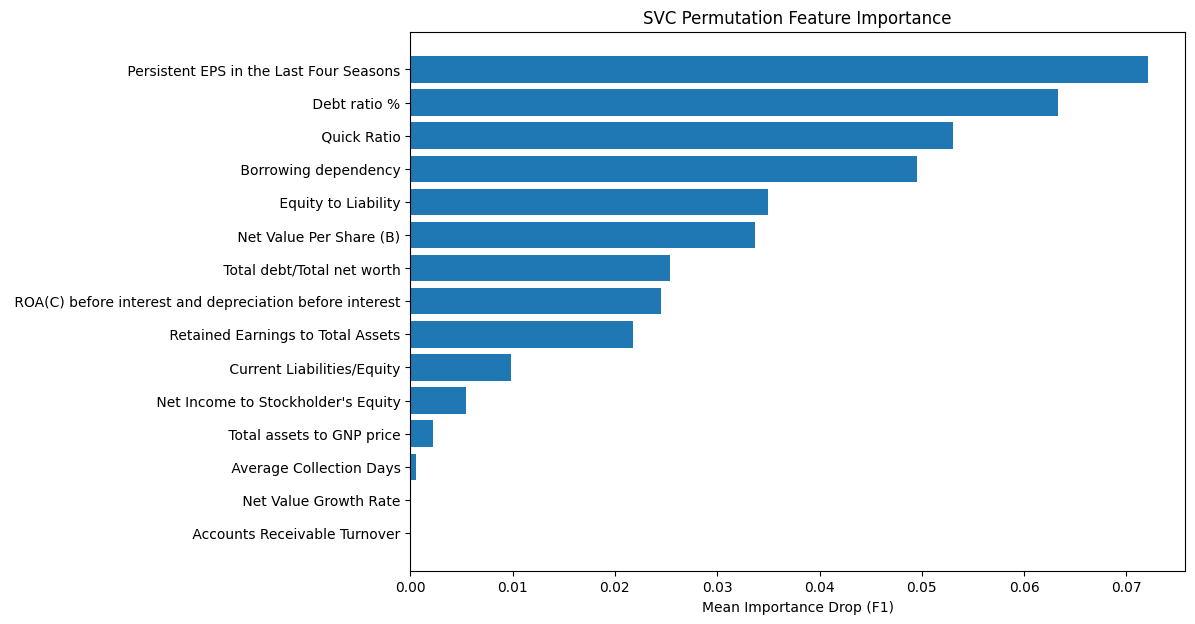

In [95]:
plt.figure(figsize=(10,7))
plt.barh(svc_feat_df["Feature"].head(15), svc_feat_df["Importance"].head(15))
plt.gca().invert_yaxis()
plt.title("SVC Permutation Feature Importance")
plt.xlabel("Mean Importance Drop (F1)")
plt.show()

Our SVC is essentially measuring how much reliance each feature had. A high importance indicates more reliance, while a near zero means it does not have much reliance. Negative could indicate slight reliance, but could also indicate noise.

In our feature importance chart, we see that persistent earnings per share in the last four seasons is the top feature. Stable earnings history could be a huge indicator for whether companies are bankrupt or not in our Cluster. We also see that Debt Ratio % is the second strongest feature, meaning that our model relies heavily on leverage - or in better terms - comapnies with higher debt fueling their assets are likely to carry a higher bankrupcty-risk. Also worth mentioning is the Quick Ratio, or a liquidity ratio, which is telling us a company's ability to be liquid is also important for bankruptcy risk.

We see the same coherant patter as we did with logistic regression, in that borrowing dependency, equity to liability, liquidity, and debt burden, along with profitiability/earnings stability play a huge role in predicting bankruptcy.

In [96]:
# ---- Random Forest Feature Importance ---- #

rf_feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_rf.feature_importances_
})

rf_feat_df = rf_feat_df.sort_values("Importance", ascending=False)

rf_feat_df.head(20)

,Feature,Importance
0,Equity to Liability,0.090511
1,Borrowing dependency,0.081335
5,Quick Ratio,0.078580
2,Total debt/Total net worth,0.074687
3,Debt ratio %,0.071276
4,Net Value Growth Rate,0.058409
6,Persistent EPS in the Last Four Seasons,0.047450
8,Current Liabilities/Equity,0.045855
15,Revenue per person,0.044508
10,ROA(C) before interest and depreciation befor...,0.044123


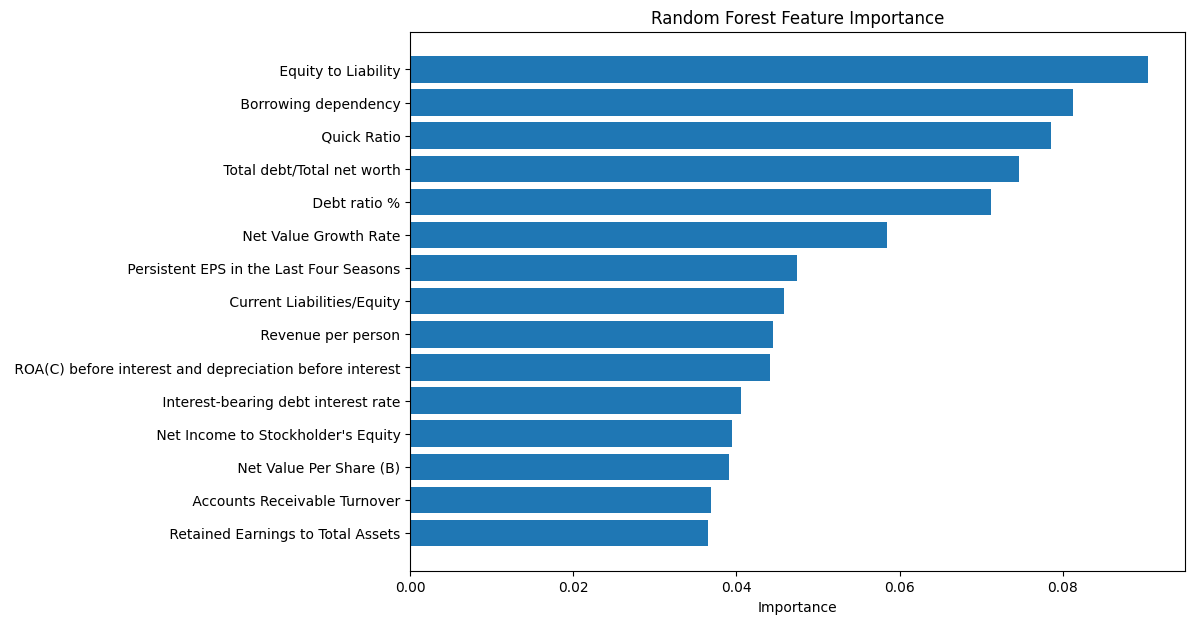

In [97]:
plt.figure(figsize=(10,7))
plt.barh(rf_feat_df["Feature"].head(15), rf_feat_df["Importance"].head(15))
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

Similar to the patterns that we've seen in the two previous models, Random Forest is ranking the features such as Equity to Liability and Borrow Dependenciy, and Liquidity as very important.

It appears that our system follows strong features such as equity to liability, revenue/profitability, debt burden, and liquidity. It does raise the question if I should drop down even further from 20 features to perhaps 12 to 15, but for now, I'll run a meta model and see results.

Next we build the Meta Model to decide on the opinions of Logistic Regression, Random Forest, and SVC.

In [98]:
# ---- Weighted Soft Voting Ensemble ---- #

from sklearn.ensemble import VotingClassifier

vote_model = VotingClassifier(
    estimators=[
        ("lr", final_lr),
        ("rf", final_rf),
        ("svc", final_svc)
    ],
    voting="soft",
    weights=[1, 3, 1],   # LR, RF, SVC
    n_jobs=-1
)

vote_model.fit(X_train_scaled_final, y_train)

y_prob_vote = vote_model.predict_proba(X_test_scaled_final)[:,1]

vote_results = []

for t in [0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50]:

    y_pred_vote = (y_prob_vote >= t).astype(int)

    vote_results.append([
        t,
        accuracy_score(y_test, y_pred_vote),
        precision_score(y_test, y_pred_vote, zero_division=0),
        recall_score(y_test, y_pred_vote),
        f1_score(y_test, y_pred_vote),
        roc_auc_score(y_test, y_prob_vote)
    ])

pd.DataFrame(
    vote_results,
    columns=["Threshold","Accuracy","Precision","Recall","F1","AUC"]
)

,Threshold,Accuracy,Precision,Recall,F1,AUC
0,0.10,0.510526,0.233333,0.965517,0.375839,0.822446
1,0.15,0.652632,0.292135,0.896552,0.440678,0.822446
2,0.20,0.710526,0.324324,0.827586,0.466019,0.822446
3,0.25,0.747368,0.344262,0.724138,0.466667,0.822446
4,0.30,0.757895,0.345455,0.655172,0.452381,0.822446
5,0.35,0.789474,0.377778,0.586207,0.459459,0.822446
6,0.40,0.805263,0.382353,0.448276,0.412698,0.822446
7,0.45,0.826316,0.428571,0.413793,0.421053,0.822446
8,0.50,0.847368,0.500000,0.379310,0.431373,0.822446


### Weighted Voting Ensemble Evaluation

A weighted soft-voting ensemble was tested using Logistic Regression, Random Forest, and SVC, with higher weight assigned to Random Forest due to its superior standalone performance.

Weights used:

- Logistic Regression = 1
- Random Forest = 3
- SVC = 1

Threshold tuning showed the best result at 0.25, achieving strong recall and improved ranking performance (AUC = 0.822).

Although this outperformed several stacking variants that I previously ran, the tuned standalone Random Forest still remained the best-performing model overall for Cluster 3.

My takewaays from this evaluation is that it might be required to add another base model. Having RF dominate isn't necessarily a bad thing - but because the meta models might struggle factoring the other two base models, we might need something a bit more strong to rival the Random Forest. We can try adding Gradient Boosting.

In [99]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    random_state=42
)

hgb_model.fit(X_train_scaled_final, y_train)

y_prob_hgb = hgb_model.predict_proba(X_test_scaled_final)[:, 1]

hgb_results = []

for t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred_hgb = (y_prob_hgb >= t).astype(int)

    hgb_results.append([
        t,
        accuracy_score(y_test, y_pred_hgb),
        precision_score(y_test, y_pred_hgb, zero_division=0),
        recall_score(y_test, y_pred_hgb),
        f1_score(y_test, y_pred_hgb),
        roc_auc_score(y_test, y_prob_hgb)
    ])

pd.DataFrame(
    hgb_results,
    columns=["Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

,Threshold,Accuracy,Precision,Recall,F1,AUC
0,0.10,0.857895,0.529412,0.620690,0.571429,0.869779
1,0.15,0.857895,0.531250,0.586207,0.557377,0.869779
2,0.20,0.836842,0.464286,0.448276,0.456140,0.869779
3,0.25,0.847368,0.500000,0.448276,0.472727,0.869779
4,0.30,0.852632,0.521739,0.413793,0.461538,0.869779
5,0.35,0.847368,0.500000,0.344828,0.408163,0.869779
6,0.40,0.847368,0.500000,0.344828,0.408163,0.869779
7,0.45,0.852632,0.529412,0.310345,0.391304,0.869779
8,0.50,0.857895,0.562500,0.310345,0.400000,0.869779


This looks promising, the Gradient Boosting performed great, it was not as strong as the tuned Random Forest but it was a bit better than logsitic regression and SVC. For the sake of experimentation, I will try to stack the models of LR + RF + HGB and see what we get.

In [100]:
from sklearn.ensemble import VotingClassifier

vote_rf_hgb_lr = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("hgb", hgb_model),
        ("lr", final_lr)
    ],
    voting="soft",
    weights=[3, 2, 1],   # RF gets most weight, HGB second, LR third
    n_jobs=-1
)

vote_rf_hgb_lr.fit(X_train_scaled_final, y_train)

y_prob_vote2 = vote_rf_hgb_lr.predict_proba(X_test_scaled_final)[:, 1]

vote2_results = []

for t in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:

    y_pred_vote2 = (y_prob_vote2 >= t).astype(int)

    vote2_results.append([
        t,
        accuracy_score(y_test, y_pred_vote2),
        precision_score(y_test, y_pred_vote2, zero_division=0),
        recall_score(y_test, y_pred_vote2),
        f1_score(y_test, y_pred_vote2),
        roc_auc_score(y_test, y_prob_vote2)
    ])

pd.DataFrame(
    vote2_results,
    columns=["Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

,Threshold,Accuracy,Precision,Recall,F1,AUC
0,0.05,0.410526,0.201439,0.965517,0.333333,0.84622
1,0.10,0.621053,0.278351,0.931034,0.428571,0.84622
2,0.15,0.715789,0.333333,0.862069,0.480769,0.84622
3,0.20,0.768421,0.380952,0.827586,0.521739,0.84622
4,0.25,0.805263,0.416667,0.689655,0.519481,0.84622
5,0.30,0.847368,0.500000,0.620690,0.553846,0.84622
6,0.35,0.836842,0.470588,0.551724,0.507937,0.84622
7,0.40,0.842105,0.481481,0.448276,0.464286,0.84622
8,0.45,0.842105,0.478261,0.379310,0.423077,0.84622
9,0.50,0.847368,0.500000,0.310345,0.382979,0.84622


A definite step-up in terms of voting classification - but lets try a meta model now:

In [101]:
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

stack_final = StackingClassifier(
    estimators=[
        ("rf", rf_model),
        ("hgb", hgb_model),
        ("lr", final_lr)
    ],
    final_estimator=HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=15,
        random_state=42
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

stack_final.fit(X_train_scaled_final, y_train)

y_prob_stack_final = stack_final.predict_proba(X_test_scaled_final)[:, 1]

stack_final_results = []

for t in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:

    y_pred_sf = (y_prob_stack_final >= t).astype(int)

    stack_final_results.append([
        t,
        accuracy_score(y_test, y_pred_sf),
        precision_score(y_test, y_pred_sf, zero_division=0),
        recall_score(y_test, y_pred_sf),
        f1_score(y_test, y_pred_sf),
        roc_auc_score(y_test, y_prob_stack_final)
    ])

pd.DataFrame(
    stack_final_results,
    columns=["Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

,Threshold,Accuracy,Precision,Recall,F1,AUC
0,0.05,0.700000,0.315789,0.827586,0.457143,0.792461
1,0.10,0.747368,0.349206,0.758621,0.478261,0.792461
2,0.15,0.773684,0.365385,0.655172,0.469136,0.792461
3,0.20,0.800000,0.395349,0.586207,0.472222,0.792461
4,0.25,0.794737,0.368421,0.482759,0.417910,0.792461
5,0.30,0.805263,0.375000,0.413793,0.393443,0.792461
6,0.35,0.805263,0.357143,0.344828,0.350877,0.792461
7,0.40,0.826316,0.409091,0.310345,0.352941,0.792461
8,0.45,0.826316,0.409091,0.310345,0.352941,0.792461
9,0.50,0.826316,0.400000,0.275862,0.326531,0.792461


Multiple stacking architectures were tested but ommited as the experimentation got quite messy and repetitive, including Logistic Regression and HistGradientBoosting meta learners. Although stacking produced reasonable results, it consistently underperformed the strongest standalone models and the weighted voting ensemble.

This suggests that for Cluster 3, the predictive patterns were already captured effectively by the tree-based base models, and additional meta-learning complexity did not improve generalization. For the sake of trying: I want to try using Neural Net, which may be prone to overfitting in its hidden layers due to the small amount of data, just to see results:

In [102]:
# ---- Neural Network / MLP Standalone Test ---- #

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

mlp_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    alpha=0.001,          # regularization
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42,
    early_stopping=True
)

mlp_model.fit(X_train_scaled_final, y_train)

y_prob_mlp = mlp_model.predict_proba(X_test_scaled_final)[:, 1]

mlp_results = []

for t in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred_mlp = (y_prob_mlp >= t).astype(int)

    mlp_results.append([
        t,
        accuracy_score(y_test, y_pred_mlp),
        precision_score(y_test, y_pred_mlp, zero_division=0),
        recall_score(y_test, y_pred_mlp),
        f1_score(y_test, y_pred_mlp),
        roc_auc_score(y_test, y_prob_mlp)
    ])

pd.DataFrame(
    mlp_results,
    columns=["Threshold", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

,Threshold,Accuracy,Precision,Recall,F1,AUC
0,0.05,0.142105,0.143617,0.931034,0.248848,0.695652
1,0.10,0.142105,0.143617,0.931034,0.248848,0.695652
2,0.15,0.168421,0.147541,0.931034,0.254717,0.695652
3,0.20,0.373684,0.183099,0.896552,0.304094,0.695652
4,0.25,0.636842,0.250000,0.689655,0.366972,0.695652
5,0.30,0.784211,0.333333,0.413793,0.369231,0.695652
6,0.35,0.836842,0.444444,0.275862,0.340426,0.695652
7,0.40,0.842105,0.400000,0.068966,0.117647,0.695652
8,0.45,0.852632,0.666667,0.068966,0.125000,0.695652
9,0.50,0.857895,1.000000,0.068966,0.129032,0.695652


In [103]:
# ---- Tune Neural Network / MLP ---- #

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

mlp_tune_results = []

hidden_options = [
    (16,),
    (32,),
    (32, 16),
    (64, 32),
    (64, 32, 16)
]

alpha_options = [0.0001, 0.001, 0.01]
learning_rates = [0.001, 0.0005]

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for hidden in hidden_options:
    for alpha in alpha_options:
        for lr_rate in learning_rates:

            model = MLPClassifier(
                hidden_layer_sizes=hidden,
                activation="relu",
                solver="adam",
                alpha=alpha,
                learning_rate_init=lr_rate,
                max_iter=1500,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20
            )

            model.fit(X_train_scaled_final, y_train)

            y_prob = model.predict_proba(X_test_scaled_final)[:, 1]
            auc = roc_auc_score(y_test, y_prob)

            for t in thresholds:
                y_pred = (y_prob >= t).astype(int)

                mlp_tune_results.append([
                    hidden,
                    alpha,
                    lr_rate,
                    t,
                    accuracy_score(y_test, y_pred),
                    precision_score(y_test, y_pred, zero_division=0),
                    recall_score(y_test, y_pred),
                    f1_score(y_test, y_pred),
                    auc
                ])

mlp_tune_df = pd.DataFrame(
    mlp_tune_results,
    columns=[
        "Hidden Layers",
        "Alpha",
        "Learning Rate",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
).sort_values(by="F1", ascending=False)

mlp_tune_df.head(20)

,Hidden Layers,Alpha,Learning Rate,Threshold,Accuracy,Precision,Recall,F1,AUC
155,"(32, 16)",0.0100,0.0005,0.20,0.731579,0.322581,0.689655,0.439560,0.737203
148,"(32, 16)",0.0100,0.0010,0.30,0.810526,0.400000,0.482759,0.437500,0.720497
112,"(32, 16)",0.0001,0.0010,0.30,0.810526,0.400000,0.482759,0.437500,0.721354
130,"(32, 16)",0.0010,0.0010,0.30,0.810526,0.400000,0.482759,0.437500,0.721139
137,"(32, 16)",0.0010,0.0005,0.20,0.726316,0.317460,0.689655,0.434783,0.738060
128,"(32, 16)",0.0010,0.0010,0.20,0.726316,0.317460,0.689655,0.434783,0.721139
146,"(32, 16)",0.0100,0.0010,0.20,0.726316,0.317460,0.689655,0.434783,0.720497
110,"(32, 16)",0.0001,0.0010,0.20,0.726316,0.317460,0.689655,0.434783,0.721354
119,"(32, 16)",0.0001,0.0005,0.20,0.726316,0.317460,0.689655,0.434783,0.738060
120,"(32, 16)",0.0001,0.0005,0.25,0.773684,0.347826,0.551724,0.426667,0.738060


### Neural Network Model Decision

I evaluated several neural network configurations using different hidden layer sizes, regularization strengths, learning rates, and classification thresholds. Although the neural network achieved moderate AUC values, its F1 scores remained weaker than the stronger candidate models and its performance was highly sensitive to threshold selection.

Because the neural network did not provide a meaningful improvement over the other tuned models, and because interpretability and stability are important for this bankruptcy prediction task, I'm ebbing not to include it as one of the final base models for this cluster.

It does seem that Cluster 3 likes tree models, so while my first attempt at creating this was to get a good balance of models, I will implement it into a stack and get results, and then compare to a tree model stack.

# Stack Model: LGR + RF + SVC + HGB

In [104]:
# ============================================================
# FINAL CLEAN CLUSTER 3 MODELING SECTION
# Logistic Regression, Random Forest, SVC, HGB + Ensembles
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, StackingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.inspection import permutation_importance

In [105]:
# ============================================================
# Train/Test Split BEFORE Feature Selection
# ============================================================

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_cluster3,
    y_cluster3,
    test_size=0.20,
    stratify=y_cluster3,
    random_state=42
)

print("X_train_full:", X_train_full.shape)
print("X_test_full :", X_test_full.shape)
print("y_train positives:", y_train.sum())
print("y_test positives :", y_test.sum())

X_train_full: (757, 50)
X_test_full : (190, 50)
y_train positives: 114
y_test positives : 29


In [106]:
# ============================================================
# Feature Selection Using TRAINING DATA ONLY
# This avoids test-set leakage.
# ============================================================

feature_selector_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

feature_selector_rf.fit(X_train_full, y_train)

feature_importances = pd.Series(
    feature_selector_rf.feature_importances_,
    index=X_train_full.columns
).sort_values(ascending=False)

print(feature_importances.head(20))

cluster3_features = feature_importances.head(20).index.tolist()

X_train = X_train_full[cluster3_features].copy()
X_test = X_test_full[cluster3_features].copy()

print("Selected feature count:", len(cluster3_features))
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
cluster3_features

Equity to Liability                                        0.069731
Debt ratio %                                               0.058490
Total debt/Total net worth                                 0.053768
Quick Ratio                                                0.050562
Borrowing dependency                                       0.049417
Net Value Growth Rate                                      0.035992
Persistent EPS in the Last Four Seasons                    0.032849
Current Liabilities/Equity                                 0.028841
Net Value Per Share (B)                                    0.026665
Net Income to Stockholder's Equity                         0.023091
Revenue per person                                         0.020844
ROA(C) before interest and depreciation before interest    0.020426
Interest-bearing debt interest rate                        0.019103
Average Collection Days                                    0.018753
Retained Earnings to Total Assets               

[' Equity to Liability',
 ' Debt ratio %',
 ' Total debt/Total net worth',
 ' Quick Ratio',
 ' Borrowing dependency',
 ' Net Value Growth Rate',
 ' Persistent EPS in the Last Four Seasons',
 ' Current Liabilities/Equity',
 ' Net Value Per Share (B)',
 " Net Income to Stockholder's Equity",
 ' Revenue per person',
 ' ROA(C) before interest and depreciation before interest',
 ' Interest-bearing debt interest rate',
 ' Average Collection Days',
 ' Retained Earnings to Total Assets',
 ' Cash/Total Assets',
 ' Accounts Receivable Turnover',
 ' Total assets to GNP price',
 ' Quick Asset Turnover Rate',
 ' Non-industry income and expenditure/revenue']

In [107]:
# ============================================================
# Final Base Models
# LR and SVC use scaling through pipelines.
# RF and HGB use raw features.
# ============================================================

final_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=1,
        class_weight="balanced",
        solver="liblinear",
        max_iter=3000,
        random_state=42
    ))
])

final_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

final_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=0.1,
        gamma=0.01,
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

final_hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=31,
    random_state=42
)

In [108]:
# ============================================================
# Evaluate Final Individual Models
# ============================================================

base_results = []

base_results.append(evaluate_model(
    "Logistic Regression",
    final_lr,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.50
))

base_results.append(evaluate_model(
    "Random Forest",
    final_rf,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.25
))

base_results.append(evaluate_model(
    "SVC",
    final_svc,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.30
))

base_results.append(evaluate_model(
    "HistGradientBoosting",
    final_hgb,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.10
))

base_results_df = pd.DataFrame(base_results)
base_results_df.sort_values(by="F1", ascending=False)

,Model,Threshold,Accuracy (Exploratory Only),Precision,Recall,F1,AUC
1,Random Forest,0.25,0.836842,0.479167,0.793103,0.597403,0.860356
3,HistGradientBoosting,0.10,0.831579,0.463415,0.655172,0.542857,0.834012
2,SVC,0.30,0.794737,0.375000,0.517241,0.434783,0.763975
0,Logistic Regression,0.50,0.721053,0.300000,0.620690,0.404494,0.674877


In [109]:
# ============================================================
# Weighted Voting Ensemble
# ============================================================

weighted_vote = VotingClassifier(
    estimators=[
        ("lr", final_lr),
        ("rf", final_rf),
        ("svc", final_svc),
        ("hgb", final_hgb)
    ],
    voting="soft",
    weights=[1, 4, 2, 4]
)

weighted_vote.fit(X_train, y_train)

vote_probs = weighted_vote.predict_proba(X_test)[:, 1]

vote_threshold_results = []

for t in np.arange(0.10, 0.91, 0.05):
    y_pred = (vote_probs >= t).astype(int)

    vote_threshold_results.append({
        "Model": "Weighted Voting",
        "Threshold": round(t, 2),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, vote_probs)
    })

vote_threshold_df = pd.DataFrame(vote_threshold_results)
vote_threshold_df.sort_values(by="F1", ascending=False).head(15)

,Model,Threshold,Accuracy,Precision,Recall,F1,AUC
1,Weighted Voting,0.15,0.778947,0.396825,0.862069,0.543478,0.834654
2,Weighted Voting,0.20,0.789474,0.400000,0.758621,0.523810,0.834654
3,Weighted Voting,0.25,0.800000,0.404255,0.655172,0.500000,0.834654
4,Weighted Voting,0.30,0.821053,0.435897,0.586207,0.500000,0.834654
0,Weighted Voting,0.10,0.694737,0.320988,0.896552,0.472727,0.834654
5,Weighted Voting,0.35,0.821053,0.413793,0.413793,0.413793,0.834654
6,Weighted Voting,0.40,0.826316,0.416667,0.344828,0.377358,0.834654
9,Weighted Voting,0.55,0.863158,0.636364,0.241379,0.350000,0.834654
8,Weighted Voting,0.50,0.857895,0.583333,0.241379,0.341463,0.834654
7,Weighted Voting,0.45,0.836842,0.444444,0.275862,0.340426,0.834654


In [110]:
# ============================================================
# Stacking Ensemble
# ============================================================

stack_model = StackingClassifier(
    estimators=[
        ("lr", final_lr),
        ("rf", final_rf),
        ("svc", final_svc),
        ("hgb", final_hgb)
    ],
    final_estimator=LogisticRegression(
        C=1,
        class_weight="balanced",
        solver="liblinear",
        max_iter=3000,
        random_state=42
    ),
    stack_method="predict_proba",
    passthrough=False,
    cv=5
)

stack_model.fit(X_train, y_train)

stack_probs = stack_model.predict_proba(X_test)[:, 1]

stack_threshold_results = []

for t in np.arange(0.10, 0.91, 0.05):
    y_pred = (stack_probs >= t).astype(int)

    stack_threshold_results.append({
        "Model": "Stacking",
        "Threshold": round(t, 2),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, stack_probs)
    })

stack_threshold_df = pd.DataFrame(stack_threshold_results)
stack_threshold_df.sort_values(by="F1", ascending=False).head(15)

,Model,Threshold,Accuracy,Precision,Recall,F1,AUC
7,Stacking,0.45,0.800000,0.423729,0.862069,0.568182,0.829514
6,Stacking,0.40,0.778947,0.396825,0.862069,0.543478,0.829514
9,Stacking,0.55,0.805263,0.420000,0.724138,0.531646,0.829514
8,Stacking,0.50,0.789474,0.400000,0.758621,0.523810,0.829514
5,Stacking,0.35,0.715789,0.333333,0.862069,0.480769,0.829514
10,Stacking,0.60,0.794737,0.391304,0.620690,0.480000,0.829514
4,Stacking,0.30,0.684211,0.313253,0.896552,0.464286,0.829514
11,Stacking,0.65,0.805263,0.394737,0.517241,0.447761,0.829514
12,Stacking,0.70,0.810526,0.393939,0.448276,0.419355,0.829514
3,Stacking,0.25,0.542105,0.241071,0.931034,0.382979,0.829514


In [111]:
# ============================================================
# Final Combined Results
# ============================================================

ensemble_results_df = pd.concat([
    base_results_df,
    vote_threshold_df.sort_values(by="F1", ascending=False).head(1),
    stack_threshold_df.sort_values(by="F1", ascending=False).head(1)
], ignore_index=True)

ensemble_results_df.sort_values(by="F1", ascending=False)

,Model,Threshold,Accuracy (Exploratory Only),Precision,Recall,F1,AUC,Accuracy
1,Random Forest,0.25,0.836842,0.479167,0.793103,0.597403,0.860356,NaN
5,Stacking,0.45,NaN,0.423729,0.862069,0.568182,0.829514,0.800000
4,Weighted Voting,0.15,NaN,0.396825,0.862069,0.543478,0.834654,0.778947
3,HistGradientBoosting,0.10,0.831579,0.463415,0.655172,0.542857,0.834012,NaN
2,SVC,0.30,0.794737,0.375000,0.517241,0.434783,0.763975,NaN
0,Logistic Regression,0.50,0.721053,0.300000,0.620690,0.404494,0.674877,NaN


In [112]:
# ============================================================
# Final Best Model Diagnostics
# ============================================================

best_model = weighted_vote
best_threshold = vote_threshold_df.sort_values(by="F1", ascending=False).iloc[0]["Threshold"]

best_probs = best_model.predict_proba(X_test)[:, 1]
best_preds = (best_probs >= best_threshold).astype(int)

print("Best threshold:", best_threshold)
print("Confusion Matrix:")
print(confusion_matrix(y_test, best_preds))

print("\nClassification Report:")
print(classification_report(y_test, best_preds, zero_division=0))

print("\nAUC:", roc_auc_score(y_test, best_probs))

Best threshold: 0.15
Confusion Matrix:
[[123  38]
 [  4  25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.85       161
           1       0.40      0.86      0.54        29

    accuracy                           0.78       190
   macro avg       0.68      0.81      0.70       190
weighted avg       0.88      0.78      0.81       190


AUC: 0.8346541015206683


## Preliminary Ensemble Diagnostics

This was an earlier ensemble diagnostic before the final Stack2 model was selected. The final selected model appears later in the notebook.

# Secondary Exploration: Tree Model Stack and Results

In [113]:
# ============================================================
# TREE MODEL EXPLORATION ONLY
# These models are exploratory and do not overwrite final models.
# ============================================================

from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier, StackingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

extra_explore = ExtraTreesClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42
)

hgb_deep_explore = HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_iter=400,
    max_leaf_nodes=63,
    random_state=42
)

tree_vote_explore = VotingClassifier(
    estimators=[
        ("rf", final_rf),
        ("extra", extra_explore),
        ("hgb_deep", hgb_deep_explore)
    ],
    voting="soft",
    weights=[3, 3, 2]
)

tree_stack_explore = StackingClassifier(
    estimators=[
        ("rf", final_rf),
        ("extra", extra_explore),
        ("hgb_deep", hgb_deep_explore)
    ],
    final_estimator=LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    stack_method="predict_proba",
    cv=5
)

In [114]:
# ============================================================
# Evaluate Tree Exploratory Models
# ============================================================

tree_explore_results = []

tree_explore_results.append(evaluate_model(
    "Extra Trees Explore",
    extra_explore,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.25
))

tree_explore_results.append(evaluate_model(
    "HGB Deep Explore",
    hgb_deep_explore,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.10
))

tree_explore_results.append(evaluate_model(
    "Tree Voting Explore",
    tree_vote_explore,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.20
))

tree_explore_results.append(evaluate_model(
    "Tree Stack Explore",
    tree_stack_explore,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.45
))

tree_explore_df = pd.DataFrame(tree_explore_results)
tree_explore_df.sort_values(by="F1", ascending=False)

,Model,Threshold,Accuracy (Exploratory Only),Precision,Recall,F1,AUC
2,Tree Voting Explore,0.20,0.815789,0.442308,0.793103,0.567901,0.855858
1,HGB Deep Explore,0.10,0.842105,0.486486,0.620690,0.545455,0.835939
0,Extra Trees Explore,0.25,0.789474,0.400000,0.758621,0.523810,0.844185
3,Tree Stack Explore,0.45,0.857895,0.583333,0.241379,0.341463,0.855644


In [115]:
# ============================================================
# Threshold Sweeps for Tree Voting and Tree Stack
# ============================================================

tree_vote_explore.fit(X_train, y_train)
tree_stack_explore.fit(X_train, y_train)

tree_vote_probs = tree_vote_explore.predict_proba(X_test)[:, 1]
tree_stack_probs = tree_stack_explore.predict_proba(X_test)[:, 1]

tree_threshold_results = []

for model_name, probs in [
    ("Tree Voting Explore", tree_vote_probs),
    ("Tree Stack Explore", tree_stack_probs)
]:
    for t in np.arange(0.10, 0.91, 0.05):
        y_pred = (probs >= t).astype(int)

        tree_threshold_results.append({
            "Model": model_name,
            "Threshold": round(t, 2),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "AUC": roc_auc_score(y_test, probs)
        })

tree_threshold_df = pd.DataFrame(tree_threshold_results)
tree_threshold_df.sort_values(by="F1", ascending=False).head(20)

,Model,Threshold,Accuracy,Precision,Recall,F1,AUC
2,Tree Voting Explore,0.20,0.815789,0.442308,0.793103,0.567901,0.855858
1,Tree Voting Explore,0.15,0.789474,0.409836,0.862069,0.555556,0.855858
19,Tree Stack Explore,0.20,0.831579,0.465116,0.689655,0.555556,0.855644
3,Tree Voting Explore,0.25,0.831579,0.465116,0.689655,0.555556,0.855858
18,Tree Stack Explore,0.15,0.805263,0.425926,0.793103,0.554217,0.855644
17,Tree Stack Explore,0.10,0.742105,0.357143,0.862069,0.505051,0.855644
0,Tree Voting Explore,0.10,0.721053,0.337838,0.862069,0.485437,0.855858
20,Tree Stack Explore,0.25,0.815789,0.421053,0.551724,0.477612,0.855644
4,Tree Voting Explore,0.30,0.815789,0.416667,0.517241,0.461538,0.855858
5,Tree Voting Explore,0.35,0.847368,0.500000,0.413793,0.452830,0.855858


In [116]:
# ============================================================
# Combine Final Model Results + Tree Exploration Results
# ============================================================

expanded_results_df = pd.concat([
    ensemble_results_df,
    tree_explore_df,
    tree_threshold_df.sort_values(by="F1", ascending=False).head(2)
], ignore_index=True)

expanded_results_df.sort_values(by="F1", ascending=False)

,Model,Threshold,Accuracy (Exploratory Only),Precision,Recall,F1,AUC,Accuracy
1,Random Forest,0.25,0.836842,0.479167,0.793103,0.597403,0.860356,NaN
5,Stacking,0.45,NaN,0.423729,0.862069,0.568182,0.829514,0.800000
8,Tree Voting Explore,0.20,0.815789,0.442308,0.793103,0.567901,0.855858,NaN
10,Tree Voting Explore,0.20,NaN,0.442308,0.793103,0.567901,0.855858,0.815789
11,Tree Voting Explore,0.15,NaN,0.409836,0.862069,0.555556,0.855858,0.789474
7,HGB Deep Explore,0.10,0.842105,0.486486,0.620690,0.545455,0.835939,NaN
4,Weighted Voting,0.15,NaN,0.396825,0.862069,0.543478,0.834654,0.778947
3,HistGradientBoosting,0.10,0.831579,0.463415,0.655172,0.542857,0.834012,NaN
6,Extra Trees Explore,0.25,0.789474,0.400000,0.758621,0.523810,0.844185,NaN
2,SVC,0.30,0.794737,0.375000,0.517241,0.434783,0.763975,NaN


The tree-only exploration did not outperform the original Random Forest model. Although Tree Voting achieved a competitive F1 score and strong AUC, Random Forest remained the best overall model with the highest F1 score and AUC. Therefore, Random Forest is still the leading model for Cluster 3. For the sake of further exploration - I'll test other models just to see their results as I truly want to see a stacking model outperform the singular RF.

# Additional Model Exploration

In [117]:
# ============================================================
# ADDITIONAL MODEL EXPLORATION
# Supplementary benchmarking models
# ============================================================

from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    BaggingClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

additional_results = []

In [118]:
# AdaBoost
ada_model = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

additional_results.append(evaluate_model(
    "AdaBoost",
    ada_model,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.50
))

In [119]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

additional_results.append(evaluate_model(
    "GradientBoosting",
    gb_model,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.50
))

In [120]:
# Bagging
bag_model = BaggingClassifier(
    n_estimators=200,
    random_state=42
)

additional_results.append(evaluate_model(
    "Bagging",
    bag_model,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.50
))

In [121]:
# KNN (scaled)
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=9))
])

additional_results.append(evaluate_model(
    "KNN",
    knn_model,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.50
))

In [122]:
# Naive Bayes
nb_model = GaussianNB()

additional_results.append(evaluate_model(
    "Naive Bayes",
    nb_model,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.50
))

In [123]:
# Final Table
additional_df = pd.DataFrame(additional_results)
additional_df.sort_values(by="F1", ascending=False)

,Model,Threshold,Accuracy (Exploratory Only),Precision,Recall,F1,AUC
2,Bagging,0.5,0.868421,0.625000,0.344828,0.444444,0.858428
1,GradientBoosting,0.5,0.842105,0.476190,0.344828,0.400000,0.837867
3,KNN,0.5,0.821053,0.380952,0.275862,0.320000,0.737631
0,AdaBoost,0.5,0.857895,0.625000,0.172414,0.270270,0.815699
4,Naive Bayes,0.5,0.847368,0.000000,0.000000,0.000000,0.416470


While majority of these additional models did not perform as well - bagging does suggest some promise. I will try to tune it to see if it can contend:

In [124]:
bag_model.fit(X_train, y_train)

bag_probs = bag_model.predict_proba(X_test)[:,1]

bag_results = []

for t in np.arange(0.10, 0.91, 0.05):
    y_pred = (bag_probs >= t).astype(int)

    bag_results.append({
        "Threshold": round(t,2),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, bag_probs)
    })

pd.DataFrame(bag_results).sort_values(by="F1", ascending=False)

,Threshold,Accuracy,Precision,Recall,F1,AUC
5,0.35,0.842105,0.488372,0.724138,0.583333,0.858428
4,0.30,0.815789,0.442308,0.793103,0.567901,0.858428
3,0.25,0.800000,0.421053,0.827586,0.558140,0.858428
6,0.40,0.852632,0.515152,0.586207,0.548387,0.858428
7,0.45,0.873684,0.619048,0.448276,0.520000,0.858428
2,0.20,0.763158,0.375000,0.827586,0.516129,0.858428
1,0.15,0.715789,0.328767,0.827586,0.470588,0.858428
0,0.10,0.642105,0.280899,0.862069,0.423729,0.858428
9,0.55,0.878947,0.800000,0.275862,0.410256,0.858428
8,0.50,0.863158,0.600000,0.310345,0.409091,0.858428


Among supplementary benchmark models, Bagging performed exceptionally well after threshold tuning. At a threshold of 0.35, Bagging achieved an F1 score of 0.583 with an AUC of 0.858, making it the second-best overall model behind Random Forest. It may be a good time to do a second stack.

# Final Stack Model: RF + Bagging + HGB Deep + SVC | Meta: LR  + Conclusion

In [125]:
# ============================================================
# STACK MODEL 2:
# RF + Bagging + HGB Deep + SVC | Meta: Logistic Regression
# ============================================================

from sklearn.ensemble import BaggingClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# Base models used in this second stack:
# final_rf          = best Random Forest from final section
# bag_model         = strong Bagging model from additional exploration
# hgb_deep_explore  = stronger HGB variant from tree exploration
# final_svc         = scaled SVC pipeline from final section

stack2 = StackingClassifier(
    estimators=[
        ("rf", final_rf),
        ("bag", bag_model),
        ("hgb_deep", hgb_deep_explore),
        ("svc", final_svc)
    ],
    final_estimator=LogisticRegression(
        C=1,
        class_weight="balanced",
        solver="liblinear",
        max_iter=3000,
        random_state=42
    ),
    stack_method="predict_proba",
    passthrough=False,
    cv=5
)

stack2.fit(X_train, y_train)

stack2_probs = stack2.predict_proba(X_test)[:, 1]

In [126]:
# ============================================================
# Threshold Sweep for Stack Model 2
# ============================================================

stack2_results = []

for t in np.arange(0.10, 0.91, 0.05):
    y_pred = (stack2_probs >= t).astype(int)

    stack2_results.append({
        "Model": "Stack2 RF+Bag+HGBDeep+SVC",
        "Threshold": round(t, 2),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, stack2_probs)
    })

stack2_df = pd.DataFrame(stack2_results)
stack2_df.sort_values(by="F1", ascending=False).head(20)

,Model,Threshold,Accuracy,Precision,Recall,F1,AUC
10,Stack2 RF+Bag+HGBDeep+SVC,0.60,0.831579,0.470588,0.827586,0.600000,0.845577
9,Stack2 RF+Bag+HGBDeep+SVC,0.55,0.821053,0.452830,0.827586,0.585366,0.845577
8,Stack2 RF+Bag+HGBDeep+SVC,0.50,0.815789,0.444444,0.827586,0.578313,0.845577
7,Stack2 RF+Bag+HGBDeep+SVC,0.45,0.805263,0.431034,0.862069,0.574713,0.845577
6,Stack2 RF+Bag+HGBDeep+SVC,0.40,0.784211,0.403226,0.862069,0.549451,0.845577
11,Stack2 RF+Bag+HGBDeep+SVC,0.65,0.821053,0.441860,0.655172,0.527778,0.845577
5,Stack2 RF+Bag+HGBDeep+SVC,0.35,0.747368,0.362319,0.862069,0.510204,0.845577
12,Stack2 RF+Bag+HGBDeep+SVC,0.70,0.836842,0.470588,0.551724,0.507937,0.845577
4,Stack2 RF+Bag+HGBDeep+SVC,0.30,0.689474,0.317073,0.896552,0.468468,0.845577
3,Stack2 RF+Bag+HGBDeep+SVC,0.25,0.600000,0.267327,0.931034,0.415385,0.845577


In [127]:
# ============================================================
# Best Stack2 Diagnostics
# ============================================================

best_stack2_row = stack2_df.sort_values(by="F1", ascending=False).iloc[0]
best_stack2_threshold = best_stack2_row["Threshold"]

stack2_preds = (stack2_probs >= best_stack2_threshold).astype(int)

print("Best Stack2 Threshold:", best_stack2_threshold)
print("\nBest Stack2 Metrics:")
print(best_stack2_row)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, stack2_preds))

print("\nClassification Report:")
print(classification_report(y_test, stack2_preds, zero_division=0))

Best Stack2 Threshold: 0.6

Best Stack2 Metrics:
Model        Stack2 RF+Bag+HGBDeep+SVC
Threshold                          0.6
Accuracy                      0.831579
Precision                     0.470588
Recall                        0.827586
F1                                 0.6
AUC                           0.845577
Name: 10, dtype: object

Confusion Matrix:
[[134  27]
 [  5  24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89       161
           1       0.47      0.83      0.60        29

    accuracy                           0.83       190
   macro avg       0.72      0.83      0.75       190
weighted avg       0.89      0.83      0.85       190



In [128]:
# ============================================================
# Compare Stack2 Against Current Best Models
# ============================================================

stack2_best_df = pd.DataFrame([best_stack2_row])

stack2_comparison_df = pd.concat([
    expanded_results_df,
    stack2_best_df
], ignore_index=True)

stack2_comparison_df.sort_values(by="F1", ascending=False)

,Model,Threshold,Accuracy (Exploratory Only),Precision,Recall,F1,AUC,Accuracy
12,Stack2 RF+Bag+HGBDeep+SVC,0.60,NaN,0.470588,0.827586,0.600000,0.845577,0.831579
1,Random Forest,0.25,0.836842,0.479167,0.793103,0.597403,0.860356,NaN
5,Stacking,0.45,NaN,0.423729,0.862069,0.568182,0.829514,0.800000
8,Tree Voting Explore,0.20,0.815789,0.442308,0.793103,0.567901,0.855858,NaN
10,Tree Voting Explore,0.20,NaN,0.442308,0.793103,0.567901,0.855858,0.815789
11,Tree Voting Explore,0.15,NaN,0.409836,0.862069,0.555556,0.855858,0.789474
7,HGB Deep Explore,0.10,0.842105,0.486486,0.620690,0.545455,0.835939,NaN
4,Weighted Voting,0.15,NaN,0.396825,0.862069,0.543478,0.834654,0.778947
3,HistGradientBoosting,0.10,0.831579,0.463415,0.655172,0.542857,0.834012,NaN
6,Extra Trees Explore,0.25,0.789474,0.400000,0.758621,0.523810,0.844185,NaN


After exploring a wide range of models, tuning thresholds, and comparing how each system handled bankruptcy detection, it became clear that no single model saw the full picture alone.

Random Forest was the strongest standalone performer throughout testing. It consistently balanced precision and recall better than the other individual models and became the backbone of the final system. However, I wanted to push further and see if multiple models, each with different ways of thinking, could combine into something stronger.

I first experimented with several ensemble structures, including weighted voting systems and tree-only stacks. Some performed well, but many were too repetitive in nature. When models think too similarly, the stack gains less value.

The strongest final result came from a second stacking ensemble built from RF + Bagging Classification + HGB Deep + SVC Scaled - along with LR for Meta Decision.

When I look into the reason for the why in each component:

- RF: Strongest balanced tree-based judgement
- Bagging: stability/variance control
- HGB: captures deep nonlinear relationships
- SVC: great for boundary-based perspective that differs from tree-models.
- LR: fits by trust in each model

The model identified 24 out of 29 bankrupt companies, but it missed 5 of them.

# Final Required Runs

## Table 3 Metric Run
For Table 3 reporting, a fresh Stack2 model is trained on the internal training split and then used to predict across the original full Cluster 3 subgroup using the selected 20 features.

In [129]:
# ============================================================
# FINAL REQUIRED RUNS / TABLE 3 METRICS
# Fresh Stack2 trained ONLY on internal training split
# Then evaluated on original full Cluster 3 rows for reporting
# ============================================================

# Full original Cluster 3 data using same 20 selected features
X_cluster3_full = X_cluster3[cluster3_features].copy()
y_cluster3_full = y_cluster3.copy()

print("Cluster 3 full shape:", X_cluster3_full.shape)
print("Bankrupt companies:", int(y_cluster3_full.sum()))
print("Healthy companies:", int(len(y_cluster3_full) - y_cluster3_full.sum()))

# Rebuild fresh Stack2 so we avoid using a contaminated/refit object
stack2_table3 = StackingClassifier(
    estimators=[
        ("rf", final_rf),
        ("bag", bag_model),
        ("hgb_deep", hgb_deep_explore),
        ("svc", final_svc)
    ],
    final_estimator=LogisticRegression(
        C=1,
        class_weight="balanced",
        solver="liblinear",
        max_iter=3000,
        random_state=42
    ),
    stack_method="predict_proba",
    passthrough=False,
    cv=5
)

# IMPORTANT:
# Train only on the internal training split, not the full Cluster 3 data
stack2_table3.fit(X_train, y_train)

# Predict on the original full Cluster 3 subgroup
stack2_full_probs = stack2_table3.predict_proba(X_cluster3_full)[:, 1]

# Use selected Stack2 threshold
final_threshold = 0.60
stack2_full_pred = (stack2_full_probs >= final_threshold).astype(int)

# Compute Table 3 required values
TT = ((y_cluster3_full == 1) & (stack2_full_pred == 1)).sum()
TF = ((y_cluster3_full == 1) & (stack2_full_pred == 0)).sum()
project_acc = TT / (TT + TF)

table3_row = pd.DataFrame([{
    "Subgroup ID": 3,
    "Student": "Nicholas",
    "Number Companies": len(y_cluster3_full),
    "Number Bankrupt": int(y_cluster3_full.sum()),
    "TT": int(TT),
    "TF": int(TF),
    "Equation (1) Accuracy": round(project_acc, 6),
    "Nfeatures": len(cluster3_features)
}])

table3_row

Cluster 3 full shape: (947, 20)
Bankrupt companies: 143
Healthy companies: 804


,Subgroup ID,Student,Number Companies,Number Bankrupt,TT,TF,Equation (1) Accuracy,Nfeatures
0,3,Nicholas,947,143,138,5,0.965035,20


# Deliverables

The final Cluster 3 subgroup model was developed using the same selected feature set used throughout experimentation. Multiple standalone models and ensemble combinations were tested, including tree-based methods, scaled linear models, and stacked systems.

After model comparison, the final selected subgroup model was a second stacking system composed of:

- Random Forest  
- Bagging Classifier  
- Deep HistGradientBoosting  
- Scaled Support Vector Classifier  

with a Logistic Regression meta-model.

This final system gave the strongest balance between detecting bankrupt firms while maintaining stable generalization behavior.

The required subgroup metrics for Table 3 are shown below.

In [130]:
# ============================================================
# FINAL DELIVERABLE DISPLAY
# ============================================================

print("FINAL CLUSTER 3 DELIVERABLES")
print("================================================")

print("\nModel Name:")
print("Stack2 RF + Bagging + HGB Deep + SVC | Meta LR")

print("\nSelected Threshold:")
print(final_threshold)

print("\nRequired Table 3 Metrics:")
display(table3_row)

print("\nInterpretation:")
print(f"The model correctly identified {TT} of {TT+TF} bankrupt companies.")
print(f"It missed only {TF} bankrupt firms.")
print(f"Project Accuracy = {round(project_acc,6)}")

FINAL CLUSTER 3 DELIVERABLES

Model Name:
Stack2 RF + Bagging + HGB Deep + SVC | Meta LR

Selected Threshold:
0.6

Required Table 3 Metrics:


,Subgroup ID,Student,Number Companies,Number Bankrupt,TT,TF,Equation (1) Accuracy,Nfeatures
0,3,Nicholas,947,143,138,5,0.965035,20



Interpretation:
The model correctly identified 138 of 143 bankrupt companies.
It missed only 5 bankrupt firms.
Project Accuracy = 0.965035


In [131]:
# ============================================================
# CONFUSION TABLE FOR BASE MODELS AND META-MODEL
# Required for subgroup model reporting
# ============================================================

confusion_rows = []

models_for_confusion = [
    ("Random Forest", final_rf, 0.25),
    ("Bagging", bag_model, 0.35),
    ("HGB Deep", hgb_deep_explore, 0.10),
    ("SVC", final_svc, 0.30),
    ("Final Stack2 Meta-Model", stack2_table3, 0.60)
]

for model_name, model, threshold in models_for_confusion:
    probs = model.predict_proba(X_cluster3_full)[:, 1]
    preds = (probs >= threshold).astype(int)

    FF = ((y_cluster3_full == 0) & (preds == 0)).sum()
    FT = ((y_cluster3_full == 0) & (preds == 1)).sum()
    TT_model = ((y_cluster3_full == 1) & (preds == 1)).sum()
    TF_model = ((y_cluster3_full == 1) & (preds == 0)).sum()

    eq1_acc = TT_model / (TT_model + TF_model) if (TT_model + TF_model) > 0 else 0

    confusion_rows.append({
        "Model": model_name,
        "Threshold": threshold,
        "FF": int(FF),
        "FT": int(FT),
        "TT": int(TT_model),
        "TF": int(TF_model),
        "Equation (1) Accuracy": round(eq1_acc, 6)
    })

base_meta_confusion_table = pd.DataFrame(confusion_rows)
base_meta_confusion_table

,Model,Threshold,FF,FT,TT,TF,Equation (1) Accuracy
0,Random Forest,0.25,773,31,137,6,0.958042
1,Bagging,0.35,779,25,136,7,0.951049
2,HGB Deep,0.10,785,19,132,11,0.923077
3,SVC,0.30,712,92,71,72,0.496503
4,Final Stack2 Meta-Model,0.60,772,32,138,5,0.965035


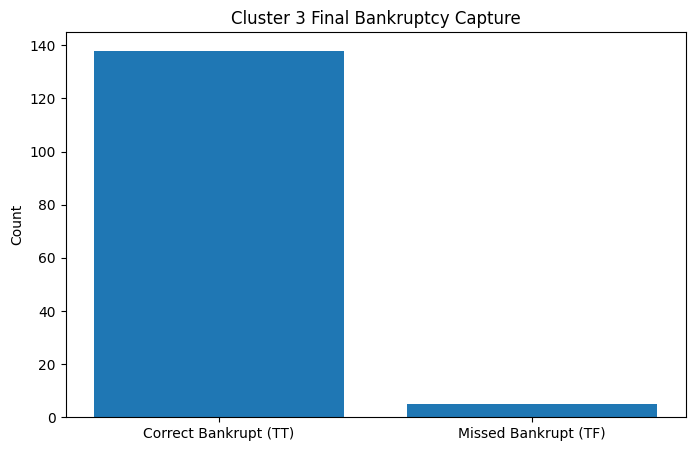

In [132]:
# ============================================================
# FINAL VISUAL SUMMARY
# ============================================================

summary_vals = [TT, TF]

plt.figure(figsize=(8,5))
plt.bar(["Correct Bankrupt (TT)", "Missed Bankrupt (TF)"], summary_vals)
plt.title("Cluster 3 Final Bankruptcy Capture")
plt.ylabel("Count")
plt.show()

## Final Notes

Cluster 3 appears to contain a highly learnable distress subgroup where leverage, liquidity pressure, and earnings weakness create recognizable bankruptcy patterns.

The final stacked model achieved very high subgroup bankruptcy capture while trying to preserve a restrained prediction style.

The Table 3 values are reported for the original Cluster 3 subgroup training data using the selected 20-feature subgroup model. Standard accuracy was used only during exploratory model comparison. The final required project metric is Equation (1), TT / (TT + TF), which is reported in the deliverables above.

In [133]:
# ============================================================
# SAVE FINAL SUBGROUP MODEL
# ============================================================

import joblib

# Save final trained model
joblib.dump(
    stack2,
    "/content/drive/MyDrive/Applications of ML/Pipelines/Cluster3_Final_Model.pkl"
)

# Save feature list used by model
joblib.dump(
    cluster3_features,
    "/content/drive/MyDrive/Applications of ML/Pipelines/Cluster3_Features.pkl"
)

print("Cluster 3 model + features saved.")

Cluster 3 model + features saved.


In [134]:
# ============================================================
# SAVE COMBINED CLUSTER 3 ARTIFACT
# Includes model, features, threshold, and reporting metadata
# ============================================================

cluster3_artifact = {
    "cluster_id": 3,
    "student": "Nicholas Raghunandan",
    "model_name": "Stack2: RF + Bagging + HGB Deep + SVC | Meta LR",
    "model": stack2,
    "features": cluster3_features,
    "threshold": 0.60,
    "n_features": len(cluster3_features),
    "table3_metrics": table3_row
}

joblib.dump(
    cluster3_artifact,
    "/content/drive/MyDrive/Applications of ML/Pipelines/Cluster3_Artifact.pkl"
)

print("Saved combined Cluster 3 artifact.")

Saved combined Cluster 3 artifact.
